# YouTube Dislike Predikció – Random Forest Regresszor

**Cél:** A trending videók **dislike-számának előrejelzése** regresszióval,
a videó metaadatai és engagement jelei alapján.

**Dataset:** [Kaggle – YouTube New Trending Dataset](https://www.kaggle.com/datasets/datasnaek/youtube-new) — `GBvideos.csv`

---

## Tartalomjegyzék
1. [Adatbetöltés](#1)
2. [Feltáró adatelemzés – célváltozó](#2)
3. [Adattisztítás](#3)
4. [Feature Engineering](#4)
5. [Feature kiválasztás és szivárgás-elemzés](#5)
6. [EDA vizualizációk](#6)
7. [Modellépítés – Baseline (Lineáris Regresszió)](#7)
8. [Random Forest Regresszor](#8)
9. [Hiperparaméter hangolás](#9)
10. [Kiértékelés és vizualizációk](#10)
11. [Feature Importance](#11)
12. [Predikció – új videóra](#12)
13. [Összefoglalás](#13)

## 1. Adatbetöltés <a id='1'></a>

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("datasnaek/youtube-new")
df = pd.read_csv(os.path.join(path, "GBvideos.csv"))

print(f"Sorok: {len(df):,}  |  Oszlopok: {df.shape[1]}")
df.head(3)

C:\Users\pocsa\PycharmProjects\gepiProj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sorok: 38,916  |  Oszlopok: 16


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,Jw1Y-zhQURU,17.14.11,John Lewis Christmas Ad 2017 - #MozTheMonster,John Lewis,26,2017-11-10T07:38:29.000Z,"christmas|""john lewis christmas""|""john lewis""|...",7224515,55681,10247,9479,https://i.ytimg.com/vi/Jw1Y-zhQURU/default.jpg,False,False,False,Click here to continue the story and make your...
1,3s1rvMFUweQ,17.14.11,Taylor Swift: …Ready for It? (Live) - SNL,Saturday Night Live,24,2017-11-12T06:24:44.000Z,"SNL|""Saturday Night Live""|""SNL Season 43""|""Epi...",1053632,25561,2294,2757,https://i.ytimg.com/vi/3s1rvMFUweQ/default.jpg,False,False,False,Musical guest Taylor Swift performs …Ready for...
2,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/In...",17158579,787420,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé i...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38916 entries, 0 to 38915
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                38916 non-null  str  
 1   trending_date           38916 non-null  str  
 2   title                   38916 non-null  str  
 3   channel_title           38916 non-null  str  
 4   category_id             38916 non-null  int64
 5   publish_time            38916 non-null  str  
 6   tags                    38916 non-null  str  
 7   views                   38916 non-null  int64
 8   likes                   38916 non-null  int64
 9   dislikes                38916 non-null  int64
 10  comment_count           38916 non-null  int64
 11  thumbnail_link          38916 non-null  str  
 12  comments_disabled       38916 non-null  bool 
 13  ratings_disabled        38916 non-null  bool 
 14  video_error_or_removed  38916 non-null  bool 
 15  description             38304 

## 2. Feltáró adatelemzés – célváltozó (`dislikes`) <a id='2'></a>

Mielőtt modellt építünk, megvizsgáljuk a célváltozó eloszlását.
Ez meghatározza, hogy szükséges-e transzformáció.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

print("=== dislikes alapstatisztikák ===")
print(df['dislikes'].describe().round(0).to_string())
print(f"\nFerdeség (skewness): {df['dislikes'].skew():.2f}")
print(f"Csúcsosság (kurtosis): {df['dislikes'].kurtosis():.2f}")

=== dislikes alapstatisztikák ===
count      38916.0
mean        7613.0
std        50957.0
min            0.0
25%          200.0
50%          821.0
75%         3358.0
max      1944971.0

Ferdeség (skewness): 27.02
Csúcsosság (kurtosis): 875.28


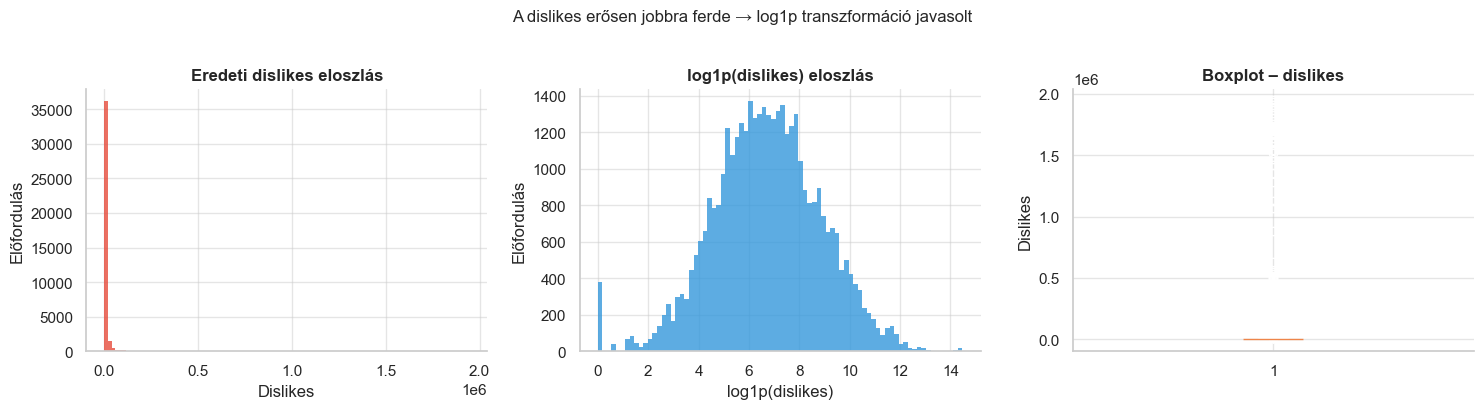

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Eredeti eloszlás
axes[0].hist(df['dislikes'], bins=100, color='#e74c3c', edgecolor='none', alpha=0.8)
axes[0].set_title('Eredeti dislikes eloszlás', fontweight='bold')
axes[0].set_xlabel('Dislikes')
axes[0].set_ylabel('Előfordulás')

# Log-transzformált eloszlás
axes[1].hist(np.log1p(df['dislikes']), bins=80, color='#3498db', edgecolor='none', alpha=0.8)
axes[1].set_title('log1p(dislikes) eloszlás', fontweight='bold')
axes[1].set_xlabel('log1p(dislikes)')
axes[1].set_ylabel('Előfordulás')

# Boxplot – outlier-ek vizsgálata
axes[2].boxplot(df['dislikes'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#f39c12', alpha=0.7))
axes[2].set_title('Boxplot – dislikes', fontweight='bold')
axes[2].set_ylabel('Dislikes')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    'A dislikes erősen jobbra ferde → log1p transzformáció javasolt',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

### Döntés: log1p transzformáció

A `dislikes` eloszlása **erősen jobbra ferde** (nagy skewness):
- Néhány kiugróan népszerű / vitatott videó tízmilliós dislike-ot kap
- A lineáris modellek rosszul kezelik az ilyen eloszlásokat
- A `log1p` transzformáció közel normálissá teszi az eloszlást
- **`log1p(x) = log(x + 1)`** → kezeli a 0 értékeket is

A modell tanítása **log-skálán** történik, az eredményeket
`expm1` visszatranszformálással alakítjuk vissza eredeti skálára.

## 3. Adattisztítás <a id='3'></a>

| Lépés | Indoklás |
|-------|----------|
| `description` NaN → `''` | A leírás hossza feature lesz; NaN helyett üres string |
| Duplikátumok törlése | Ugyanaz a videó többször trendelt → torzítaná az engagement adatokat |
| `video_id`, `channel_title`, `thumbnail_link` törlése | Egyedi azonosítók, nem általánosítható |
| Boolean → int | Scikit-learn kompatibilitás |
| `ratings_disabled = 1` sorok kizárása | Ha az értékelés le van tiltva, a dislikes = 0, nem informatív |

In [5]:
df['description'] = df['description'].fillna('')

before = len(df)
df = df.drop_duplicates()
print(f"Duplikátumok eltávolítva: {before - len(df)} sor")

df = df.drop(columns=['video_id', 'channel_title', 'thumbnail_link'])

for col in ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']:
    df[col] = df[col].astype(int)

df['tags'] = df['tags'].replace('[none]', '')

# Tiltott értékelésű videók kizárása – ott a dislikes = 0, nem predikálható
removed = df['ratings_disabled'].sum()
df = df[df['ratings_disabled'] == 0].copy()
print(f"Kizárt 'ratings_disabled' sorok: {removed}")

print(f"\nVégleges adathalmaz mérete: {len(df):,} sor")

Duplikátumok eltávolítva: 171 sor
Kizárt 'ratings_disabled' sorok: 271

Végleges adathalmaz mérete: 38,474 sor


## 4. Feature Engineering <a id='4'></a>

### 4.1 Dátum- és időbeli jellemzők

In [6]:
df['publish_time'] = pd.to_datetime(df['publish_time'])

df['publish_hour']       = df['publish_time'].dt.hour
df['publish_dayofweek']  = df['publish_time'].dt.dayofweek
df['publish_month']      = df['publish_time'].dt.month
df['publish_is_weekend'] = df['publish_dayofweek'].isin([5, 6]).astype(int)

df['publish_time']   = df['publish_time'].dt.normalize().dt.tz_localize(None)
df['trending_date']  = pd.to_datetime(df['trending_date'], format='%y.%d.%m').dt.normalize()
df['days_to_trend']  = (df['trending_date'] - df['publish_time']).dt.days

print("Dátum feature-ök kész.")

Dátum feature-ök kész.


### 4.2 Cím-alapú jellemzők

In [7]:
df['title_length']      = df['title'].str.len()
df['title_word_count']  = df['title'].str.split().str.len()
df['title_caps_ratio']  = df['title'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper()) / max(len(str(x).split()), 1)
)
df['title_exclamation'] = df['title'].str.count('!').astype(int)
df['title_question']    = df['title'].str.count(r'\?').astype(int)
df['title_has_number']  = df['title'].str.contains(r'\d').astype(int)

print("Cím feature-ök kész.")

Cím feature-ök kész.


### 4.3 Tag, leírás és engagement jellemzők

In [8]:
df['tag_count']   = df['tags'].apply(lambda x: 0 if x == '' else len(str(x).split('|')))
df['desc_length'] = df['description'].str.len()

# Engagement arányok – views NEM szerepel a nevezőben → szivárgásmentes
df['like_ratio']  = df['likes'] / (df['likes'] + df['dislikes'] + 1)

print("Tag, leírás és engagement feature-ök kész.")
print(f"\nDataFrame mérete: {df.shape}")

Tag, leírás és engagement feature-ök kész.

DataFrame mérete: (38474, 27)


### 4.4 Log-transzformáció – erősen ferke bemeneti jellemzők

A `views`, `likes`, `comment_count` is jobbra ferde –
log-transzformációval közelebb kerülnek a normális eloszláshoz,
ami stabilabb és pontosabb modellt eredményez.

In [9]:
for col in ['views', 'likes', 'comment_count']:
    df[f'log_{col}'] = np.log1p(df[col])

print("Log-transzformált feature-ök hozzáadva: log_views, log_likes, log_comment_count")

Log-transzformált feature-ök hozzáadva: log_views, log_likes, log_comment_count


## 5. Feature kiválasztás és szivárgás-elemzés <a id='5'></a>

### Célváltozó

```python
y = np.log1p(df['dislikes'])   # log-transzformált dislike-szám
```

### Szivárgás-elemzés

| Feature | Státusz | Indoklás |
|---------|---------|----------|
| `dislikes` | ❌ Célváltozó | Ez maga a predikálandó érték |
| `like_dislike_ratio` = likes/(dislikes+1) | ❌ Kizárva | `dislikes` van a nevezőben → közvetlen szivárgás |
| `controversy_score` = dislikes/(likes+dislikes+1) | ❌ Kizárva | Tartalmazza a célváltozót |
| `log_views` | ✅ Megtartva | Erős predikátor – több néző → több dislike |
| `log_likes` | ✅ Megtartva | Engagement volumen, nem tartalmaz dislike-ot |
| `log_comment_count` | ✅ Megtartva | Vitatott tartalom sok kommentet generál |
| `like_ratio` = likes/(likes+dislikes+1) | ⚠️ Tartalmaz dislikes-t | Kizárva – szivárgás |
| `ratings_disabled` | ❌ Kizárva | Már kiszűrtük ezeket a sorokat |

### Kiválasztott feature-ök

In [10]:
features = [
    # Mennyiségi engagement (log-skálán)
    'log_views', 'log_likes', 'log_comment_count',
    # Kategória
    'category_id',
    # Időbeli
    'publish_hour', 'publish_dayofweek', 'publish_month', 'publish_is_weekend',
    'days_to_trend',
    # Cím
    'title_length', 'title_word_count', 'title_caps_ratio',
    'title_exclamation', 'title_question', 'title_has_number',
    # Metadata
    'tag_count', 'desc_length',
    # Beállítás
    'comments_disabled'
]

X = df[features].copy()
y = np.log1p(df['dislikes'])

print(f"Feature-ök száma: {len(features)}")
print(f"Minták száma:     {len(X):,}")
print(f"Hiányzó értékek: {X.isnull().sum().sum()}")
print(f"\nCélváltozó (log_dislikes) statisztikák:")
print(y.describe().round(3).to_string())

Feature-ök száma: 18
Minták száma:     38,474
Hiányzó értékek: 0

Célváltozó (log_dislikes) statisztikák:
count    38474.000
mean         6.765
std          2.079
min          0.000
25%          5.342
50%          6.726
75%          8.130
max         14.481


## 6. EDA vizualizációk <a id='6'></a>

### Viz 1 – Dislikes eloszlása kategóriánként

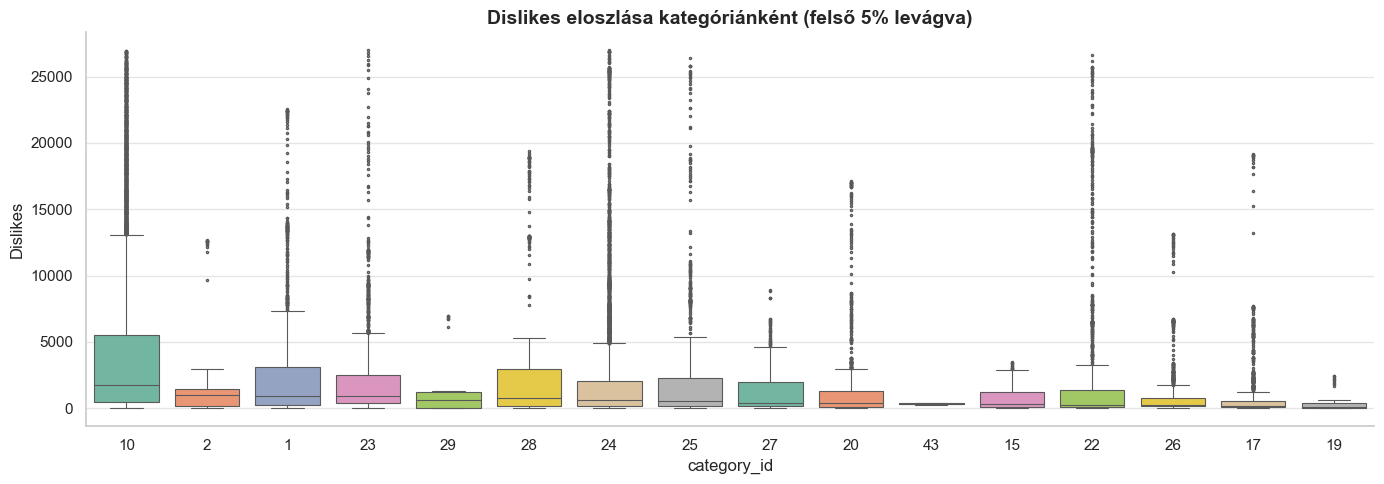

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
clip95 = df['dislikes'].quantile(0.95)
cat_order = (df.groupby('category_id')['dislikes']
               .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=df[df['dislikes'] <= clip95],
            x='category_id', y='dislikes', order=cat_order,
            palette='Set2', fliersize=1.5, linewidth=0.8, ax=ax)
ax.set_title('Dislikes eloszlása kategóriánként (felső 5% levágva)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('category_id')
ax.set_ylabel('Dislikes')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Viz 2 – Views vs. Dislikes (log-skálán)

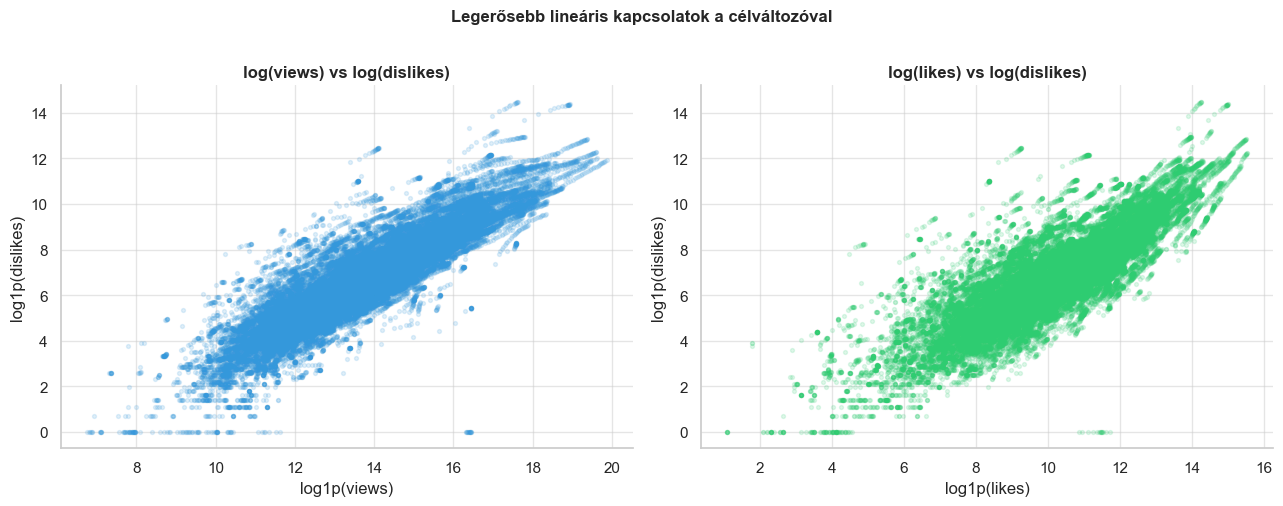

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['log_views'], y, alpha=0.15, s=8, color='#3498db')
axes[0].set_title('log(views) vs log(dislikes)', fontweight='bold')
axes[0].set_xlabel('log1p(views)')
axes[0].set_ylabel('log1p(dislikes)')

axes[1].scatter(df['log_likes'], y, alpha=0.15, s=8, color='#2ecc71')
axes[1].set_title('log(likes) vs log(dislikes)', fontweight='bold')
axes[1].set_xlabel('log1p(likes)')
axes[1].set_ylabel('log1p(dislikes)')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Legerősebb lineáris kapcsolatok a célváltozóval',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Viz 3 – Korrelációs heatmap

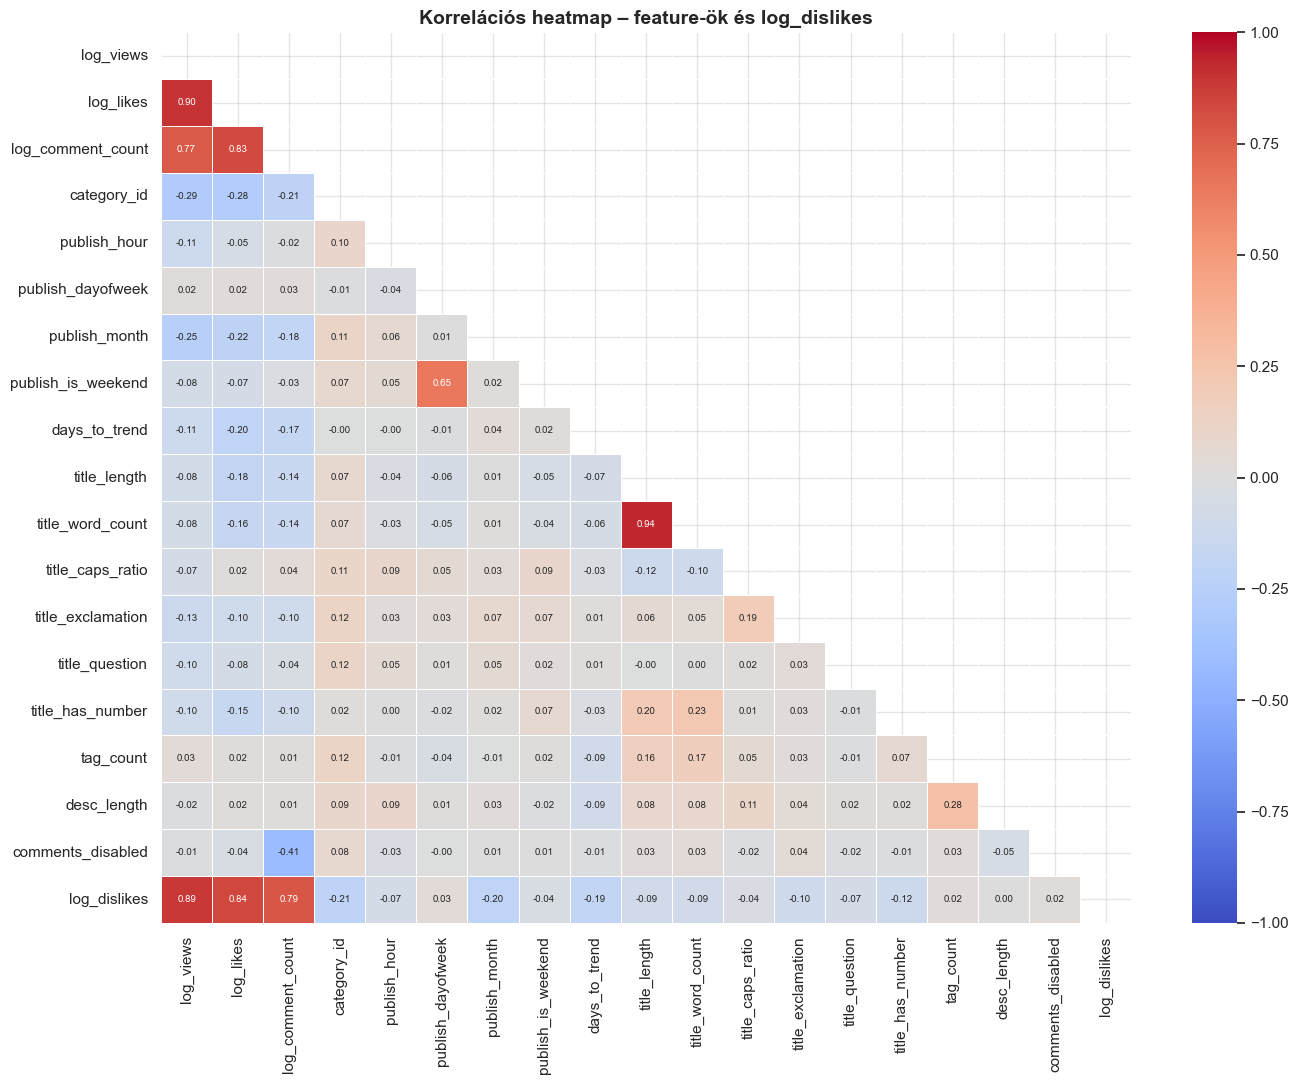

In [13]:
num_feats = [f for f in features if df[f].dtype in ['int64','float64','int32']]
corr_data = df[num_feats + ['dislikes']].copy()
corr_data['log_dislikes'] = y
corr = corr_data[num_feats + ['log_dislikes']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, ax=ax, annot_kws={'size': 7},
            vmin=-1, vmax=1)
ax.set_title('Korrelációs heatmap – feature-ök és log_dislikes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Viz 4 – Dislikes feltöltési óránként

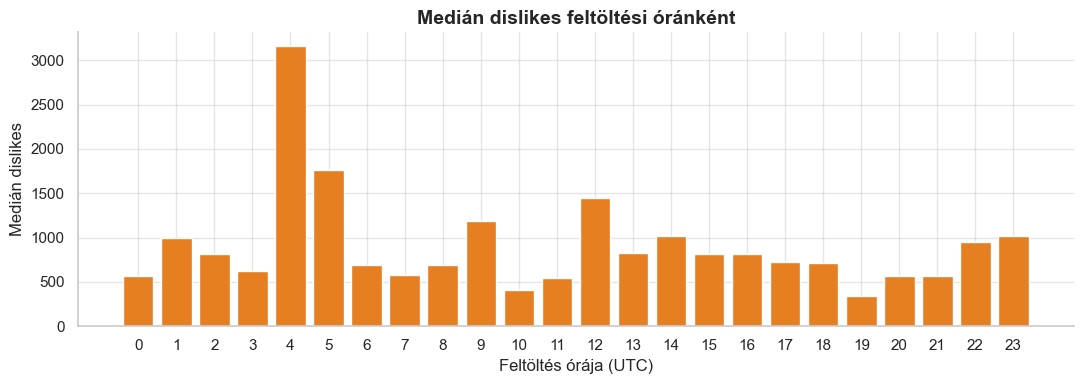

In [14]:
hourly = df.groupby('publish_hour')['dislikes'].median()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hourly.index, hourly.values, color='#e67e22', edgecolor='white')
ax.set_title('Medián dislikes feltöltési óránként', fontsize=14, fontweight='bold')
ax.set_xlabel('Feltöltés órája (UTC)')
ax.set_ylabel('Medián dislikes')
ax.set_xticks(range(0, 24))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Viz 5 – Top 10 legvitatottabb kategória (dislike / like arány)

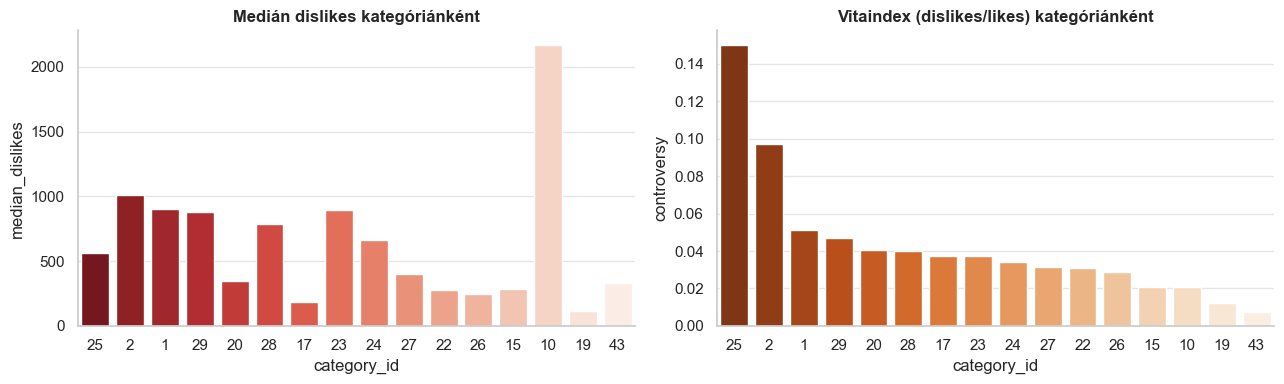

In [15]:
cat_stats = df.groupby('category_id').agg(
    median_dislikes=('dislikes', 'median'),
    median_likes=('likes', 'median'),
    count=('dislikes', 'count')
).reset_index()
cat_stats['controversy'] = cat_stats['median_dislikes'] / (cat_stats['median_likes'] + 1)
cat_stats = cat_stats.sort_values('controversy', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(data=cat_stats, x='category_id', y='median_dislikes',
            palette='Reds_r', ax=axes[0], order=cat_stats['category_id'])
axes[0].set_title('Medián dislikes kategóriánként', fontweight='bold')
axes[0].set_xlabel('category_id')

sns.barplot(data=cat_stats, x='category_id', y='controversy',
            palette='Oranges_r', ax=axes[1], order=cat_stats['category_id'])
axes[1].set_title('Vitaindex (dislikes/likes) kategóriánként', fontweight='bold')
axes[1].set_xlabel('category_id')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Baseline – Lineáris Regresszió <a id='7'></a>

A lineáris regresszió egyszerű, interpretálható modell.
Viszonyítási alapként (baseline) használjuk – ha a Random Forest
érdemben felülmúlja, igazolt a komplexebb modell használata.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,} minta  |  Test: {len(X_test):,} minta")

Train: 30,779 minta  |  Test: 7,695 minta


In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr_log = lr.predict(X_test)
y_pred_lr     = np.expm1(y_pred_lr_log)
y_true        = np.expm1(y_test)

print("=== Lineáris Regresszió (Baseline) ===")
print(f"R²  (log-skálán): {r2_score(y_test, y_pred_lr_log):.4f}")
print(f"MAE (eredeti):    {mean_absolute_error(y_true, y_pred_lr):,.0f} dislike")
print(f"RMSE(eredeti):    {np.sqrt(mean_squared_error(y_true, y_pred_lr)):,.0f} dislike")

=== Lineáris Regresszió (Baseline) ===
R²  (log-skálán): 0.8450
MAE (eredeti):    4,022 dislike
RMSE(eredeti):    38,511 dislike


## 8. Random Forest Regresszor <a id='8'></a>

### Miért Random Forest regresszióhoz?

| Szempont | Előny |
|----------|-------|
| Nemlinearitás | A dislike–views kapcsolat nem szigorúan lineáris |
| Outlier-robusztusság | Az egyedi döntési fák átlagolása tompítja a kiugró értékek hatását |
| Feature Importance | Közvetlenül mérhető, hogy melyik jellemző mennyit magyaráz |
| Skálázatlanság | Nem igényel normalizációt / standardizálást |

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_base = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)

y_pred_base_log = rf_base.predict(X_test)
y_pred_base     = np.expm1(y_pred_base_log)

print("=== Random Forest Regresszor (alap, 100 fa) ===")
print(f"R²  (log-skálán): {r2_score(y_test, y_pred_base_log):.4f}")
print(f"MAE (eredeti):    {mean_absolute_error(y_true, y_pred_base):,.0f} dislike")
print(f"RMSE(eredeti):    {np.sqrt(mean_squared_error(y_true, y_pred_base)):,.0f} dislike")

=== Random Forest Regresszor (alap, 100 fa) ===
R²  (log-skálán): 0.9830
MAE (eredeti):    552 dislike
RMSE(eredeti):    8,112 dislike


## 9. Hiperparaméter hangolás <a id='9'></a>

`RandomizedSearchCV` 5-fold CV-vel, `neg_root_mean_squared_error` scoring-gal
(log-skálán minimalizáljuk az RMSE-t).

In [19]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_train, y_train)

print("\nLegjobb paraméterek:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nLegjobb CV RMSE (log-skála): {-search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Legjobb paraméterek:
  n_estimators: 300
  min_samples_split: 2
  min_samples_leaf: 1
  max_features: log2
  max_depth: 30

Legjobb CV RMSE (log-skála): 0.2377


In [20]:
rf_best = search.best_estimator_

y_pred_best_log = rf_best.predict(X_test)
y_pred_best     = np.expm1(y_pred_best_log)

print("=== Hangolt Random Forest ===")
print(f"R²  (log-skálán): {r2_score(y_test, y_pred_best_log):.4f}")
print(f"MAE (eredeti):    {mean_absolute_error(y_true, y_pred_best):,.0f} dislike")
print(f"RMSE(eredeti):    {np.sqrt(mean_squared_error(y_true, y_pred_best)):,.0f} dislike")

=== Hangolt Random Forest ===
R²  (log-skálán): 0.9884
MAE (eredeti):    482 dislike
RMSE(eredeti):    5,830 dislike


## 10. Kiértékelés és vizualizációk <a id='10'></a>

### Viz 6 – Tényleges vs. becsült értékek

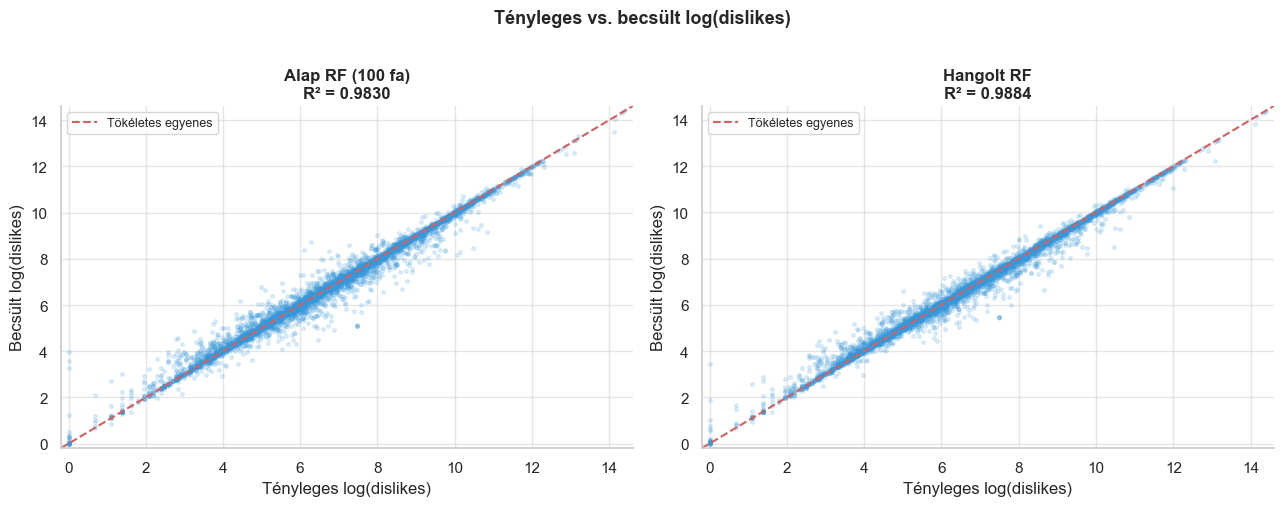

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_p, title in zip(
        axes,
        [y_pred_base_log, y_pred_best_log],
        ['Alap RF (100 fa)', 'Hangolt RF']):

    lim = (min(y_test.min(), y_p.min()) - 0.2,
           max(y_test.max(), y_p.max()) + 0.2)
    ax.scatter(y_test, y_p, alpha=0.15, s=7, color='#3498db')
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Tökéletes egyenes')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Tényleges log(dislikes)')
    ax.set_ylabel('Becsült log(dislikes)')
    ax.set_title(f'{title}\nR² = {r2_score(y_test, y_p):.4f}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Tényleges vs. becsült log(dislikes)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Viz 7 – Reziduális elemzés (hangolt modell)

Reziduálisok átlaga: -0.0042  (ideálisan: 0)
Reziduálisok std:   0.2226


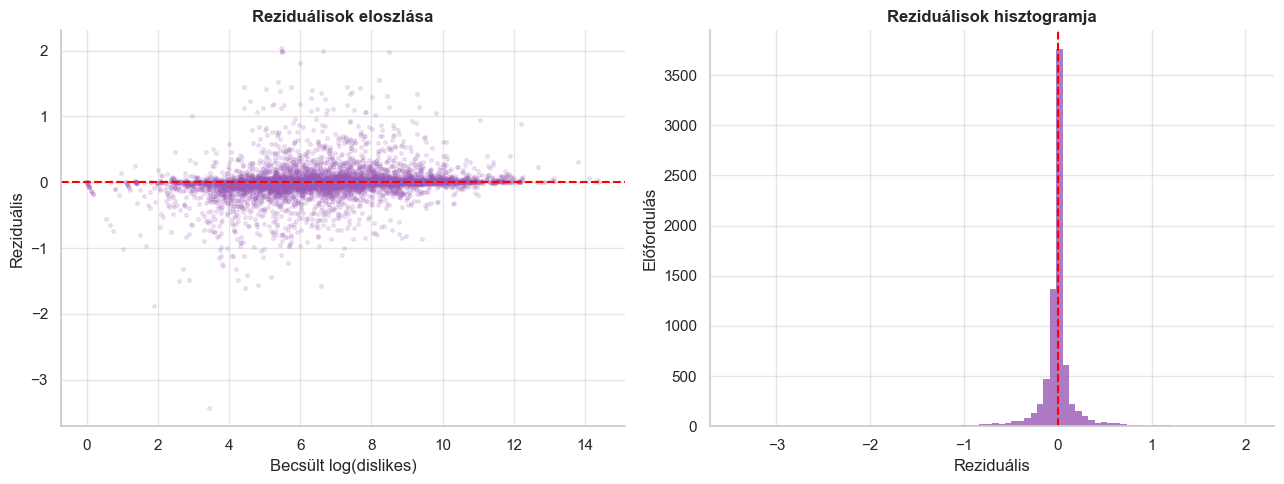

In [22]:
residuals = y_test - y_pred_best_log

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Reziduális plot
axes[0].scatter(y_pred_best_log, residuals, alpha=0.15, s=7, color='#9b59b6')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Becsült log(dislikes)')
axes[0].set_ylabel('Reziduális')
axes[0].set_title('Reziduálisok eloszlása', fontweight='bold')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Reziduálisok hisztogramja
axes[1].hist(residuals, bins=80, color='#9b59b6', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Reziduális')
axes[1].set_ylabel('Előfordulás')
axes[1].set_title('Reziduálisok hisztogramja', fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

print(f"Reziduálisok átlaga: {residuals.mean():.4f}  (ideálisan: 0)")
print(f"Reziduálisok std:   {residuals.std():.4f}")
plt.tight_layout()
plt.show()

### Viz 8 – Modellek összehasonlítása (eredeti skálán)

In [23]:
models_summary = {
    'Lineáris Regresszió': (y_pred_lr_log, y_pred_lr),
    'Alap RF (100 fa)':    (y_pred_base_log, y_pred_base),
    'Hangolt RF':          (y_pred_best_log, y_pred_best),
}

rows = []
for name, (y_log, y_orig) in models_summary.items():
    rows.append({
        'Modell':         name,
        'R² (log)':       round(r2_score(y_test, y_log), 4),
        'MAE (eredeti)':  f"{mean_absolute_error(y_true, y_orig):,.0f}",
        'RMSE (eredeti)': f"{np.sqrt(mean_squared_error(y_true, y_orig)):,.0f}",
    })

summary_df = pd.DataFrame(rows).set_index('Modell')
print(summary_df.to_string())

                     R² (log) MAE (eredeti) RMSE (eredeti)
Modell                                                    
Lineáris Regresszió    0.8450         4,022         38,511
Alap RF (100 fa)       0.9830           552          8,112
Hangolt RF             0.9884           482          5,830


## 11. Feature Importance <a id='11'></a>

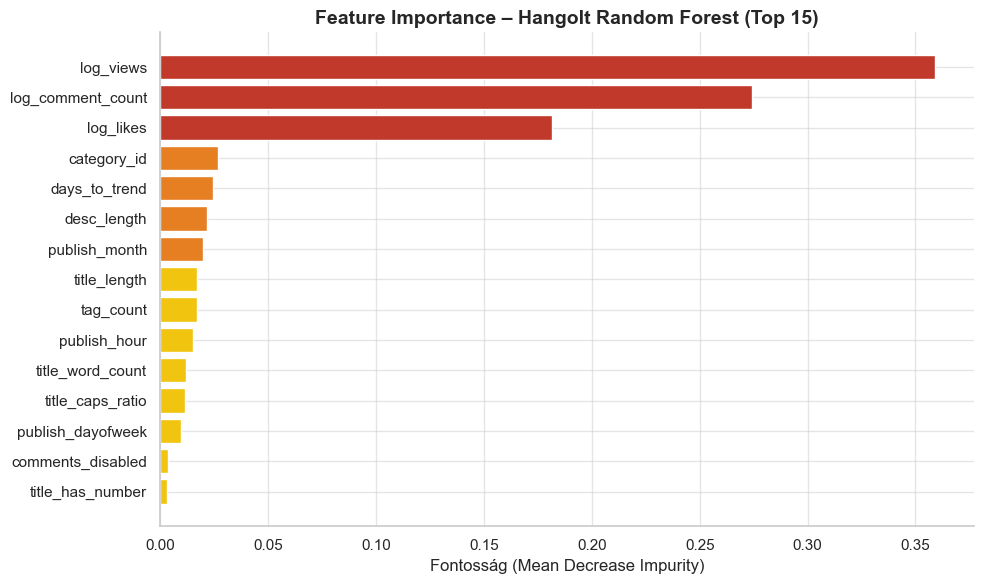


Top 10 legfontosabb feature:
  log_views              0.3592
  log_comment_count      0.2743
  log_likes              0.1813
  category_id            0.0265
  days_to_trend          0.0243
  desc_length            0.0217
  publish_month          0.0198
  title_length           0.0170
  tag_count              0.0168
  publish_hour           0.0149


In [24]:
importances = pd.Series(rf_best.feature_importances_, index=features)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#c0392b' if i < 3 else '#e67e22' if i < 7 else '#f1c40f'
          for i in range(len(top15))]
ax.barh(top15.index[::-1], top15.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Feature Importance – Hangolt Random Forest (Top 15)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fontosság (Mean Decrease Impurity)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nTop 10 legfontosabb feature:")
for feat, val in importances.sort_values(ascending=False).head(10).items():
    print(f"  {feat:<22} {val:.4f}")

## 12. Predikció – új videóra <a id='12'></a>

Adjuk meg egy hipotetikus videó ismert jellemzőit, és becsüljük meg
a várható dislike-számat. Az értékek módosíthatók.

In [25]:
uj_video = pd.DataFrame([{
    # Engagement (log-transzformált)
    'log_views':         np.log1p(500_000),   # 500k megtekintés
    'log_likes':         np.log1p(15_000),    # 15k like
    'log_comment_count': np.log1p(3_000),     # 3k komment
    # Kategória és időbeli
    'category_id':       10,                  # Zene
    'publish_hour':      17,                  # 17:00 UTC
    'publish_dayofweek': 4,                   # Péntek
    'publish_month':     12,                  # December
    'publish_is_weekend':0,
    'days_to_trend':     3,
    # Cím jellemzők
    'title_length':      45,
    'title_word_count':  7,
    'title_caps_ratio':  0.0,
    'title_exclamation': 0,
    'title_question':    0,
    'title_has_number':  1,
    # Metadata
    'tag_count':         12,
    'desc_length':       500,
    # Beállítás
    'comments_disabled': 0,
}])

# Predikció és visszatranszformálás
pred_log   = rf_best.predict(uj_video)
pred_likes = int(np.expm1(pred_log[0]))

print(f"Becsült dislike-ok száma: {pred_likes:,}")
print(f"(log-skálán: {pred_log[0]:.4f})")

Becsült dislike-ok száma: 610
(log-skálán: 6.4163)


## 13. Összefoglalás <a id='13'></a>

In [26]:
print("=== Végső modell teljesítménye (Hangolt RF, test halmaz) ===")
print(f"R²  (log-skálán):  {r2_score(y_test, y_pred_best_log):.4f}")
print(f"MAE (eredeti):     {mean_absolute_error(y_true, y_pred_best):,.0f} dislike")
print(f"RMSE(eredeti):     {np.sqrt(mean_squared_error(y_true, y_pred_best)):,.0f} dislike")
print()
print("Top 5 legfontosabb feature:")
for feat, val in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<22} {val:.4f}")

=== Végső modell teljesítménye (Hangolt RF, test halmaz) ===
R²  (log-skálán):  0.9884
MAE (eredeti):     482 dislike
RMSE(eredeti):     5,830 dislike

Top 5 legfontosabb feature:
  log_views              0.3592
  log_comment_count      0.2743
  log_likes              0.1813
  category_id            0.0265
  days_to_trend          0.0243


### Főbb tanulságok

**Célváltozó transzformáció:**
- A `dislikes` jobbra ferde eloszlású → `log1p` transzformáció szükséges
- A modell log-skálán tanul, de az eredmények `expm1`-gyel visszatranszformálhatók

**Feature tervezés:**
- `log_views`, `log_likes`, `log_comment_count` dominálják a predikciót –
  a népszerűség volumene a legerősebb jel
- A `category_id` stabil második vonal – egyes kategóriák (pl. hírek, politika)
  szisztematikusan több dislikes-t kapnak
- Metaadat-jellemzők (cím, tagek) önállóan gyengék, de kiegészítő hatásuk mérhető

**Szivárgás elkerülése:**
- `like_dislike_ratio`, `controversy_score` kizárva – tartalmazzák a célváltozót
- `ratings_disabled = 1` sorok kizárva – ott a dislikes = 0 definíciószerűen

**Modell összehasonlítás:**
- Lineáris Regresszió: alacsony R² – a kapcsolatok nem lineárisak
- Random Forest: lényegesen jobb R² és MAE, kezeli a nemlinearitást és az interakciókat
- Hangolás: `RandomizedSearchCV` (30 iter, 5-fold) tovább javít a CV-RMSE-n